In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score
from datetime import timedelta
from xgboost import XGBClassifier
import os
from scipy.stats import entropy
from scipy.stats import uniform, randint
from joblib import Parallel, delayed
import ast



import sys
init_dir = os.getcwd()  

In [3]:
consumer_df = pd.read_parquet(init_dir + '/cashflow-data/consumer_data.parquet')
transactions = pd.read_parquet(init_dir + '/cashflow-data/transactions.parquet')

In [4]:
consumer_df['evaluation_date'] = pd.to_datetime(consumer_df['evaluation_date'])
transactions['posted_date'] = pd.to_datetime(transactions['posted_date'])
transactions_df = transactions.merge(
    consumer_df[['masked_consumer_id', 'evaluation_date', 'FPF_TARGET']],
    on='masked_consumer_id',
    how='left'
)
transactions_df = transactions_df[transactions_df['posted_date'] < transactions_df['evaluation_date']]
transactions_df['month'] = transactions_df['posted_date'].dt.to_period('M')
transactions_df['posted_date'] = pd.to_datetime(transactions_df['posted_date'])
transactions_df['converted_date'] = (max(transactions_df['posted_date']) - transactions_df['posted_date']).dt.total_seconds()/3600
# transactions_df = transactions_df[transactions_df['masked_consumer_id'].str[2] == '4']

In [5]:
df_4 = transactions_df
df_4

,masked_consumer_id,posted_date,amount,category,masked_transaction_id,evaluation_date,FPF_TARGET,month,converted_date
0,C02103629,2022-08-12,-21.00,27.0,C02T02715977,2022-11-16,1.0,2022-08,8472.0
1,C02103629,2022-08-09,-8.60,22.0,C02T02715978,2022-11-16,1.0,2022-08,8544.0
2,C02103629,2022-08-07,-30.05,16.0,C02T02715979,2022-11-16,1.0,2022-08,8592.0
3,C02103629,2022-09-29,-0.46,0.0,C02T02715980,2022-11-16,1.0,2022-09,7320.0
4,C02103629,2022-07-21,-50.00,12.0,C02T02715981,2022-11-16,1.0,2022-07,9000.0
...,...,...,...,...,...,...,...,...,...
17738078,C04100784,2021-05-24,-84.96,22.0,C04T01072780,2022-03-31,1.0,2021-05,19152.0
17738079,C04100784,2021-05-24,-25.00,15.0,C04T01072781,2022-03-31,1.0,2021-05,19152.0
17738080,C04100784,2021-05-26,-1.00,1.0,C04T01072782,2022-03-31,1.0,2021-05,19104.0
17738081,C04100784,2021-05-26,-5.00,1.0,C04T01072783,2022-03-31,1.0,2021-05,19104.0


In [6]:
# import pandas as pd

# def process_user_parallel(user_id, group, ranges=24*7, num_categories=36):
#     start = group['converted_date'].min()
#     end = group['converted_date'].max()

#     segments = []
#     for x in range(int(start), int(end), ranges):
#         mask = group[(group['converted_date'] >= x) & (group['converted_date'] < x + ranges)]
#         if len(mask) == 0 or (mask['converted_date'].min() + ranges >  end):
#             continue

#         data = {
#             'net_week_series': mask['amount'].sum(),
#             'count_week_series': mask['amount'].count(),
#             'inflow_week_series': mask[mask['amount'] > 0]['amount'].sum(),
#             'outflow_week_series': mask[mask['amount'] < 0]['amount'].sum(),
#         }
#         for i in range(num_categories):
#             data[f"week_series_category_{i}"] = mask[mask['category'] == i]['amount'].sum()
#         segments.append(data)

#     if len(segments) == 0:
#         return user_id, pd.Series({
#             key: [0] 
#             for key in ['net_week_series', 'count_week_series', 'inflow_week_series', 'outflow_week_series'] +
#                        [f"week_series_category_{i}" for i in range(num_categories)]
#         })

#     segments = segments[::-1]
#     output = {key: [seg[key] for seg in segments] for key in segments[0].keys()}
#     return user_id, pd.Series(output)

# # Split by user 
# grouped = list(df_4.groupby('masked_consumer_id'))

# # Parallel processing
# results = Parallel(n_jobs=-1)(delayed(process_user_parallel)(uid, grp) for uid, grp in grouped)

# # Combine results
# transaction_grouped = pd.DataFrame({uid: out for uid, out in results}).T.reset_index().rename(columns={'index': 'masked_consumer_id'})
# transaction_grouped.set_index('masked_consumer_id').to_csv(init_dir + '/cashflow-data/features.csv')

In [7]:
transaction_grouped = pd.read_csv(init_dir + '/cashflow-data/features.csv',)
for col in transaction_grouped.columns[1:]:
    transaction_grouped[col] = transaction_grouped[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

def compute_trend(series):
    if not isinstance(series, list) or len(series) < 3:
        return 0  # insufficient data

    series = np.array(series)
    nonzero_idx = np.nonzero(series)[0]
    nonzero_vals = series[nonzero_idx]

    if len(nonzero_vals) <= 2 or len(nonzero_vals) / len(series) < 0.1:
        return 0  # too sparse to infer meaningful trend

    # Option: Apply smoothing if noise/spikes are common
    if len(series) >= 5:
        window = min(3, len(series))  # rolling window size
        smoothed = pd.Series(series).rolling(window=window, min_periods=1, center=True).mean().values
        series = smoothed
        nonzero_idx = np.nonzero(series)[0]
        nonzero_vals = series[nonzero_idx]

    X = nonzero_idx.reshape(-1, 1)
    y = nonzero_vals
    model = LinearRegression().fit(X, y)
    return round(model.coef_[0], 5)  # limit decimal noise


# Apply to each time series column
trend_df = pd.DataFrame()
trend_df['masked_consumer_id'] = transaction_grouped['masked_consumer_id']

# All time-series columns
series_cols = transaction_grouped.columns.drop('masked_consumer_id')

for col in series_cols:
    trend_df[col + '_trend'] = transaction_grouped[col].apply(compute_trend)

trend_df.head()


,masked_consumer_id,net_week_series_trend,count_week_series_trend,inflow_week_series_trend,outflow_week_series_trend,week_series_category_0_trend,week_series_category_1_trend,week_series_category_2_trend,week_series_category_3_trend,week_series_category_4_trend,...,week_series_category_26_trend,week_series_category_27_trend,week_series_category_28_trend,week_series_category_29_trend,week_series_category_30_trend,week_series_category_31_trend,week_series_category_32_trend,week_series_category_33_trend,week_series_category_34_trend,week_series_category_35_trend
0,C01100001,-3.07333,-0.19584,-104.65573,101.58240,-81.76610,85.30931,-24.66778,-6.47100,-1.98833,...,0.52254,0.07486,1.69547,0.0,0.00000,0.0,0.0,0.0,0.00000,0.0
1,C01100002,-10.57191,-0.07611,-26.54109,15.96918,0.00000,-5.90068,1.63860,-43.78478,-36.77967,...,6.75152,1.30956,0.00000,0.0,0.00000,0.0,0.0,0.0,0.00000,0.0
2,C01100003,1.91374,0.03781,7.84843,-5.93468,-0.35188,1.14586,-9.03350,-7.35431,0.00000,...,0.14827,0.00000,0.04869,0.0,0.00000,0.0,0.0,0.0,3.22989,0.0
3,C01100004,1.58399,-0.11605,-0.01379,1.59778,-1.81802,6.14896,-0.20846,0.00000,0.48448,...,1.79775,0.24856,-0.38094,0.0,0.00000,0.0,0.0,0.0,0.00000,0.0
4,C01100005,7.96790,0.03290,4.09049,3.87741,-0.62068,15.88092,-1.08045,0.00000,-1.04138,...,-18.06672,-0.56186,-0.60970,0.0,0.89029,0.0,0.0,0.0,0.00000,0.0


In [ ]:
# Step 2: Feature Engineering
# Create debit/credit indicators
df_4['is_credit'] = df_4['amount'] > 0
df_4['is_debit'] = df_4['amount'] < 0

# Compute aggregate features
agg = df_4.groupby('masked_consumer_id').agg(
    total_amount=('amount', 'sum'),
    mean_amount=('amount', 'mean'),
    std_amount=('amount', 'std'),
    min_amount=('amount', 'min'),
    max_amount=('amount', 'max'),
    median_amount=('amount', 'median'),
    transaction_count=('amount', 'count'),
    credit_sum=('is_credit', lambda x: df_4.loc[x.index, 'amount'][x].sum()),
    debit_sum=('is_debit', lambda x: abs(df_4.loc[x.index, 'amount'][x].sum()))
)

# Ratio of credits to debits
agg['credit_debit_ratio'] = agg['credit_sum'] / agg['debit_sum'].replace(0, np.nan)
agg['credit_debit_ratio'] = agg['credit_debit_ratio'].fillna(0)

# Recent 30-day transaction features
df_4['days_before_eval'] = (df_4['evaluation_date'] - df_4['posted_date']).dt.days
recent_df = df_4[df_4['days_before_eval'] <= 30].groupby('masked_consumer_id').agg(
    recent30_sum=('amount', 'sum'),
    recent30_count=('amount', 'count')
)

# Monthly cashflow volatility: std / mean
df_4['month'] = df_4['posted_date'].dt.to_period('M')
monthly_cashflow = df_4.groupby(['masked_consumer_id', 'month'])['amount'].sum().reset_index()
monthly_stats = monthly_cashflow.groupby('masked_consumer_id')['amount'].agg(['mean', 'std']).rename(
    columns={'mean': 'monthly_mean', 'std': 'monthly_std'}
)
monthly_stats['monthly_cv'] = monthly_stats['monthly_std'] / monthly_stats['monthly_mean'].replace(0, np.nan)
monthly_stats = monthly_stats.fillna(0)

# category
cat_encode = pd.get_dummies(df_4, columns = ['category'], drop_first = False)
cat_encode.rename(columns = {f"category_{i}.0": f"category_{i}_mean" for i in range(36)}, inplace = True)
cat_encode_mean = cat_encode.groupby('masked_consumer_id').agg({f"category_{i}_mean": 'sum' for i in range(36)})


# weekend vs weekday transactions
df_4['weekday'] = df_4['posted_date'].dt.weekday
df_4['is_weekend'] = df_4['weekday'] >= 5

weekend_spend = df_4[df_4['amount'] > 0].groupby(['masked_consumer_id', 'is_weekend'])['amount'].sum().unstack(fill_value=0)
weekend_spend.columns = ['weekday_spending', 'weekend_spending']
weekend_spend['weekend_ratio'] = weekend_spend['weekend_spending'] / (weekend_spend['weekday_spending'] + 1e-6)

# Transaction frequency and span
txn_freq = df_4.groupby('masked_consumer_id').agg(
    unique_txn_days=('posted_date', lambda x: x.nunique()),
    txn_days_span=('posted_date', lambda x: (x.max() - x.min()).days + 1),
)
txn_freq['txn_per_day'] = txn_freq['unique_txn_days'] / txn_freq['txn_days_span'].replace(0, 1)

# percentiles of transaction amounts
percentiles = df_4.groupby('masked_consumer_id')['amount'].quantile([0.25, 0.75, 0.9]).unstack()
percentiles.columns = ['amount_25pct', 'amount_75pct', 'amount_90pct']

# number of large transactions
threshold = 1000  
df_4['is_large'] = df_4['amount'].abs() > threshold
large_txns = df_4.groupby('masked_consumer_id')['is_large'].sum().rename('large_txn_count')
trend_df2 = trend_df.set_index('masked_consumer_id').div(agg['credit_sum'], axis =  'index')

monthly_txn_std = df_4.groupby(['masked_consumer_id', 'month'])['amount'].std().groupby('masked_consumer_id').mean()
monthly_txn_std = monthly_txn_std.rename('monthly_avg_txn_std')
# Merge all features

merge_df = consumer_df[consumer_df['masked_consumer_id'].str[2] == '4']
features_df = merge_df.set_index('masked_consumer_id') \
    .join(trend_df2, how='left') \
    .join(agg, how='left') \
    .join(recent_df, how='left') \
    .join(monthly_stats, how='left') \
    .join(cat_encode_mean, how='left') \
    .join(txn_freq, how='left') \
    .join(weekend_spend, how='left') \
    .join(large_txns, how='left') \
    .join(monthly_txn_std, how='left') \
    .join(percentiles, how='left') \
    

In [176]:
merge_df = consumer_df[consumer_df['masked_consumer_id'].str[2] == '4']
features_df = merge_df.set_index('masked_consumer_id') \
    .join(trend_df2, how='left') \
    .join(agg, how='left') \
    .join(recent_df, how='left') \
    .join(monthly_stats, how='left') \
    .join(cat_encode_mean, how='left') \
    .join(txn_freq, how='left') \
    .join(weekend_spend, how='left') \
    .join(large_txns, how='left') 

In [177]:
# import matplotlib.pyplot as plt
# import pandas as pd

# bins = [-np.inf,-2,-1,-0.02, -0.01,-0.005, 0, 0.005, 0.01, 0.02, 1, 2, np.inf]
# features_df['trend_bin'] = pd.cut(features_df['week_series_category_4_trend'], bins = bins)

# # Aggregate FPF_TARGET by trend bin
# agg = features_df.groupby('trend_bin')['FPF_TARGET'].mean()

# # Plot
# plt.figure(figsize=(8, 5))
# agg.plot(kind='bar', color='skyblue', edgecolor='black')
# plt.title('Average FPF_TARGET by inflow_week_series_trend')
# plt.ylabel('Average FPF_TARGET')
# plt.xlabel('Trend Category')
# plt.xticks(rotation=45)
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

In [253]:
from sklearn.metrics import classification_report
# Step 3: Train-Test Split
X = features_df.drop(columns=['FPF_TARGET', 'evaluation_date', ])
y = features_df['FPF_TARGET']
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.20, )
X_val = X_val.replace([np.inf, -np.inf], np.nan)
X_val = X_val.fillna(0)  
X_train = X_train.replace([np.inf, -np.inf], np.nan)
# Step 4: Pipeline with Imputation and Logistic Regression
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('model', XGBClassifier(n_estimators=100, learning_rate=0.05,  max_depth = 5, eval_metric = 'auc',))
])

pipeline.fit(X_train, y_train)
y_train_pred = pipeline.predict_proba(X_train)[:, 1]
y_val_pred = pipeline.predict_proba(X_val)[:, 1]
train_auc = roc_auc_score(y_train, y_train_pred) 
val_auc = roc_auc_score(y_val, y_val_pred)
print(f"Train AUC: {train_auc:.4f}, Validation AUC: {val_auc:.4f}")


Train AUC: 0.9995, Validation AUC: 0.6821


In [225]:
y_val_pred[y_val_pred > 0.2] 

array([0.40319735, 0.20079185, 0.32597977, 0.28912076, 0.36544356,
       0.27981457, 0.21287715, 0.26770464, 0.20231508, 0.27413657,
       0.25536147], dtype=float32)

<Axes: >

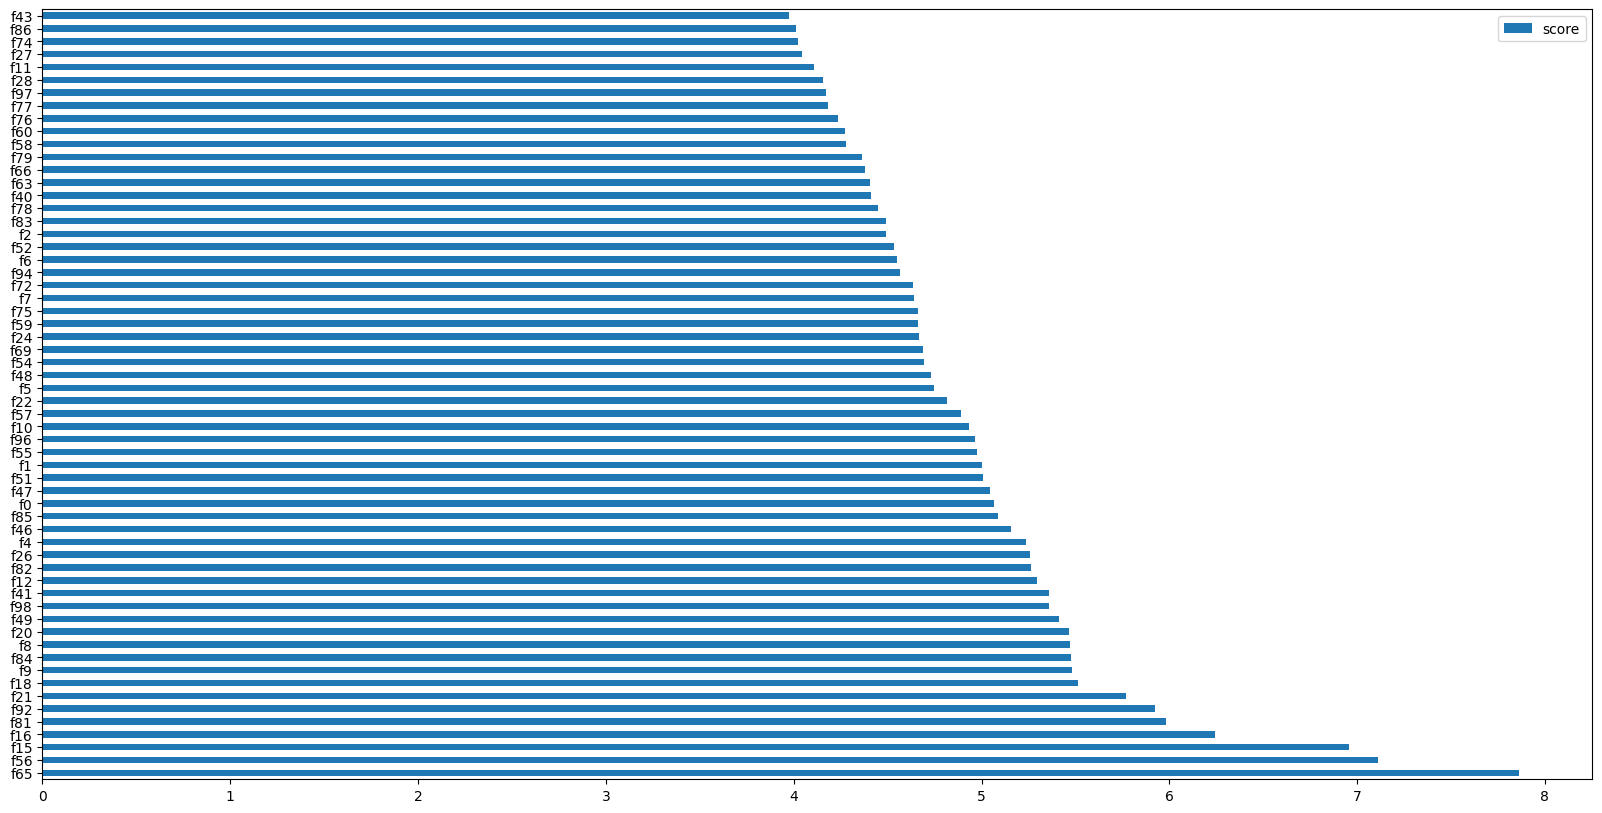

In [226]:
feature_important = pipeline['model'].get_booster().get_score(importance_type='gain')
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(60, columns="score").plot(kind='barh', figsize = (20,10)) 

In [227]:
for x in data.index:
    print(X_train.columns[int(x[1:])]) 

category_9_mean
category_0_mean
week_series_category_10_trend
week_series_category_11_trend
category_25_mean
unique_txn_days
week_series_category_16_trend
week_series_category_13_trend
week_series_category_4_trend
category_28_mean
week_series_category_3_trend
week_series_category_15_trend
debit_sum
large_txn_count
total_amount
week_series_category_7_trend
category_26_mean
week_series_category_21_trend
outflow_week_series_trend
median_amount
category_29_mean
total_balance
transaction_count
recent30_sum
net_week_series_trend
monthly_cv
weekend_spending
week_series_category_5_trend
category_1_mean
week_series_category_17_trend
week_series_category_0_trend
credit_sum
monthly_std
category_13_mean
week_series_category_19_trend
category_3_mean
category_19_mean
week_series_category_2_trend
category_16_mean
txn_per_day
week_series_category_1_trend
recent30_count
count_week_series_trend
category_27_mean
category_22_mean
week_series_category_35_trend
category_7_mean
category_10_mean
category_23_m

In [14]:
categories_val = []
for x in [1,2,3,4]:
    cur_features = features_df[features_df.index.str[2] == str(x)].drop(columns=['FPF_TARGET', 'evaluation_date'])
    y_val_pred = pipeline.predict_proba(X_val[X_val.index.str[2] == str(x)])[:, 1]
    categories_val.append(roc_auc_score(y_val[y_val.index.str[2] == str(x)], y_val_pred))
    print(f'Val AUC for category {x}: {categories_val[-1]:.4f}')


ValueError: Found array with 0 sample(s) (shape=(0, 99)) while a minimum of 1 is required by SimpleImputer.

In [ ]:
features_df

,evaluation_date,FPF_TARGET,total_balance,net_series_trend,count_series_trend,inflow_series_trend,outflow_series_trend,series_category_0_trend,series_category_1_trend,series_category_2_trend,...,series_category_26_trend,series_category_27_trend,series_category_28_trend,series_category_29_trend,series_category_30_trend,series_category_31_trend,series_category_32_trend,series_category_33_trend,series_category_34_trend,series_category_35_trend
masked_consumer_id,,,,,,,,,,,,,,,,,,,,,
C04100001,2021-08-01,0.0,34412.26,-4.953125e-07,9.226359e-07,0.000175,-0.000176,0.000025,-0.000105,0.000041,...,-3.237092e-06,2.059452e-06,0.000000,0.000000,4.714961e-07,0.0,0.0,0.0,0.000000,0.000000
C04100002,2021-08-02,0.0,5124.76,4.740694e-05,1.449822e-06,0.000347,-0.000300,0.000191,-0.000261,-0.000087,...,9.680100e-07,8.211383e-06,0.000004,0.000000,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000
C04100003,2021-10-13,0.0,1959.64,-6.166237e-06,6.315157e-07,0.000017,-0.000067,0.000000,0.000143,-0.000157,...,0.000000e+00,-1.197393e-06,0.000000,0.000000,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000
C04100004,2021-08-02,0.0,3176.35,-2.505678e-05,-1.371911e-07,0.000247,-0.000272,0.000122,-0.000239,-0.000095,...,-5.114769e-05,-3.283893e-06,0.000000,0.000000,2.403101e-06,0.0,0.0,0.0,0.000000,-0.000009
C04100005,2021-08-02,0.0,140.59,-1.309657e-03,3.491717e-05,0.004320,0.001550,0.000000,-0.001141,0.000000,...,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C04104996,2023-03-31,0.0,1412.80,5.023229e-06,2.811479e-06,0.000118,-0.000065,0.000014,0.000060,-0.000230,...,-6.462352e-05,1.409495e-05,0.000117,0.000015,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000
C04104997,2023-03-31,0.0,-439.21,-5.622663e-05,-1.205012e-06,-0.000117,0.000096,0.000270,0.000023,-0.000105,...,0.000000e+00,-1.888363e-05,0.000002,0.000002,2.234292e-05,0.0,0.0,0.0,0.000000,0.000000
C04104998,2023-03-31,0.0,84.53,-1.561547e-06,-1.154765e-06,0.000112,-0.000027,-0.000025,-0.000018,0.000000,...,-3.183857e-05,-3.136508e-05,0.000011,0.000000,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000


In [ ]:
import seaborn as sns
x = features_df.drop(columns = ['evaluation_date']).corr()
x['FPF_TARGET'].sort_values(ascending = False, )

FPF_TARGET                  1.000000
series_category_10_trend    0.035704
series_category_12_trend    0.032732
series_category_20_trend    0.031708
series_category_18_trend    0.029111
series_category_15_trend    0.026493
series_category_16_trend    0.023486
series_category_0_trend     0.022399
series_category_25_trend    0.015028
series_category_34_trend    0.014042
series_category_32_trend    0.009308
series_category_21_trend    0.007358
series_category_35_trend    0.005118
series_category_2_trend     0.004671
series_category_19_trend    0.003620
series_category_26_trend    0.001605
outflow_series_trend        0.000665
count_series_trend          0.000283
series_category_14_trend    0.000228
series_category_22_trend    0.000221
series_category_7_trend    -0.001348
series_category_29_trend   -0.001617
series_category_33_trend   -0.004830
net_series_trend           -0.005221
series_category_24_trend   -0.005285
series_category_3_trend    -0.005433
series_category_5_trend    -0.005433
s